In [1]:
from functions import *
import hw2 

Initializing Ts, Tg, ts, tg

In [2]:
T_base_eff = np.copy(hw2.T_base_eff)
T_w_eff2 = np.copy(hw2.T_w_eff2)
T_w_eff_out = np.copy(hw2.T_w_eff_out)

Ts = np.copy(T_base_eff)
Tg = np.copy(T_w_eff_out)
print(Tg)

ts = log_pose(Ts)
tg = log_pose(Tg)

[[ 1.   0.   0.  17.5]
 [ 0.   0.   1.  10. ]
 [ 0.  -1.   0.  10. ]
 [ 0.   0.   0.   1. ]]


Initializing Vs, Vg

In [3]:
Vs = twist() #default is zero twist
Vg = twist()

Coeff calculation

In [4]:
T = 15 #period
c0, c1, c2, c3 = calculate_coeffs(ts, tg, Vs, Vg, T)
#print(c0.flatten(), '\n', c1.flatten(), '\n', c2.flatten(), '\n', c3.flatten())

Trajectory

In [5]:
step = 0.2
time = np.arange(0, T+step, step)
T_traj = [exp_pose(c3 * t**3 + c2 * t**2 + c1*t + c0) for t in time]
print(T_traj[-1] - Tg)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [6]:
VelocityComm = 1    
angles_list = 3

IK for every frame

In [7]:
if not VelocityComm:
    max_error = 5e-3
    a = np.copy(hw2.a)
    T_forward = hw2.T_forward
    # T_forward = T_base_eff
    # print(T_forward)
    # a = np.array([-0.3733,  0.8654,  0.7957, -1.4039, -0.6417, -1.1399,  0.5138])
    angleslist = [np.copy(a)]

    expS = [expm(hw2.S_hat[i] * a[i]) for i in range(len(hw2.S))]

    for frame in T_traj[1:]:
        Vb = log_pose(np.linalg.inv(T_forward) @ frame)
        
        c = 0
        while np.linalg.norm(Vb) > max_error:
            c += 1

            Jw_mat = compute_Jw(expS, hw2.S)  

            Jb = Adj(np.linalg.inv(T_forward)) @ Jw_mat  

            Jb_pinv = np.linalg.pinv(Jb)
            dq = Jb_pinv @ Vb  
            
            a = a + dq.flatten()
            a = clip(a)  

            expS = [expm(hw2.S_hat[i] * a[i]) for i in range(len(hw2.S))]
            T_forward = np.eye(4)
            for e in expS:
                T_forward = T_forward @ e
            T_forward = T_forward @ T_base_eff  

            Vb = log_pose(np.linalg.inv(T_forward) @ frame)  

            # if not all([
            #     -160 <= a[0] <= 160, -70 <= a[1] <= 115, -170 <= a[2] <= 170,
            #     -113 <= a[3] <= 75, -170 <= a[4] <= 170, -115 <= a[5] <= 115,
            #     -180 <= a[6] <= 180
            # ]):
            #     out_of_limits = 1
            if c==1000: print("not converged"); break
        angleslist.append(a.copy())

    # print(len(angleslist))
    a_list = np.array2string(
        np.array(angleslist),
        precision=4,
        separator=',',
        suppress_small=True
    )
    print(a_list)

    filename = f"angleslist{angles_list}.txt"

    with open(filename, "w") as f:
        for a in angleslist:
            f.write(" ".join(map(str, a)) + "\n")

Velocity with Euler

In [8]:
if VelocityComm:
    max_error = 5e-3
    dt = 0.01         # timestep

    a = np.copy(hw2.a)
    T_forward = hw2.T_forward

    angleslist = [a.copy()]

    Kp = 7.5
    Ki = 0.1
    Vb_int = np.zeros(6)

    for frame in T_traj[1:]:

        # forward kinematics
        expS = [expm(hw2.S_hat[i] * a[i]) for i in range(len(hw2.S))]
        T_forward = np.eye(4)
        for e in expS:
            T_forward = T_forward @ e
        T_forward = T_forward @ T_base_eff

        # body error
        Vb = log_pose(np.linalg.inv(T_forward) @ frame)
        Vb = Vb.flatten()
        Vb_int += Vb * dt
        Vb_int = np.clip(Vb_int, -0.5, 0.5)
        Vb_ctrl = Kp * Vb + Ki * Vb_int

        # jacobians
        Jw_mat = compute_Jw(expS, hw2.S)
        Jb = Adj(np.linalg.inv(T_forward)) @ Jw_mat

        # velocity command (joint space)
        qdot = np.linalg.pinv(Jb) @ Vb_ctrl
        damping = 0.1
        qdot -= damping * qdot

        # velocity limit
        qdot = np.clip(qdot, -5.0, 5.0)

        # euler integration
        for _ in range(10):
            a = a + qdot.flatten() * dt
            a = clip(a)

        angleslist.append(a.copy())

    # a_list = np.array2string(
    #     np.array(angleslist),
    #     precision=4,
    #     separator=',',
    #     suppress_small=True
    # )
    # print(a_list)

    # --------- SAVE ANGLE LIST ----------

    filename = f"angleslist{angles_list}.txt"

    with open(filename, "w") as f:
        for a in angleslist:
            f.write(" ".join(map(str, a)) + "\n")

Visualize

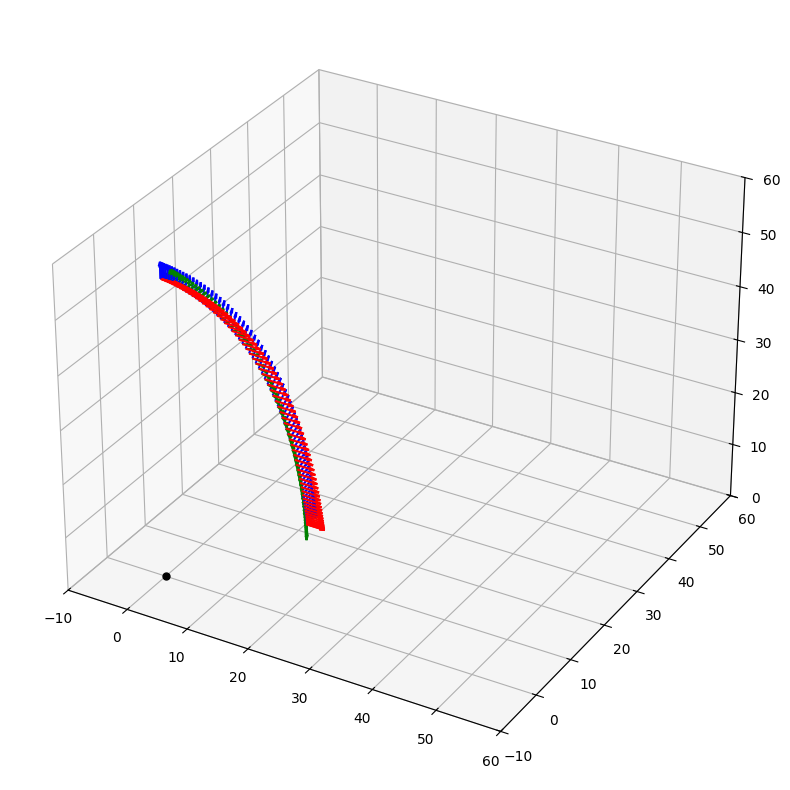

In [9]:
if True:
    fig = plt.figure(figsize = (10,10))
    ax = plt.axes(projection='3d')
    ax.set_xlim(-10, 60)
    ax.set_ylim(-10, 60)
    ax.set_zlim(0, 60)

    def draw_frame(T):
        colors = ['r', 'g', 'b']
        for i in range(len(T)-1):
            ax.quiver(*T[:3, -1], *T[:3, i], color=colors[i], length=3)
        return 1

    for frame in T_traj:
        draw_frame(frame)

    ax.scatter(0, 0, 0, color='k', s=25)

    plt.show()

